## Fine-tuning EfficientNet-B0

In [ ]:
import os
import cv2
import pandas as pd
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score

CONFIG = {
    "model_name": "efficientnet_b0", # Can be 'resnet50' or 'convnext_tiny'
    "batch_size": 32,
    "epochs": 3,
    "lr": 3e-4,
    "img_size": 224,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "num_workers": 0
}

print(f"Using device: {CONFIG['device']}")


class YelpImageDataset(Dataset):
    def __init__(self, csv_file, root_dirs, transform=None, label_encoder=None):
        self.df = pd.read_csv(csv_file)
        self.root_dirs = root_dirs
        self.transform = transform
        self.label_encoder = label_encoder
        
        if self.label_encoder:
            self.df['label_idx'] = self.label_encoder.transform(self.df['label'])
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        photo_id = row['photo_id']
        
        image = None
        found_path = None
        
        for root in self.root_dirs:
            try_path = os.path.join(root, f"{photo_id}.jpg")
            
            if os.path.exists(try_path):
                image = cv2.imread(try_path)
                if image is not None:
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    found_path = try_path
                    break
        
        if image is None:
            print(f"Warning: Image not found {photo_id}")
            image = np.zeros((224, 224, 3), dtype=np.uint8)
            
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = row['label_idx']
        return image, torch.tensor(label, dtype=torch.long)


Using device: cuda


In [13]:
# ImageNet statistics for normalization
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(1, 16), hole_width_range=(1, 16), p=0.2),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

In [14]:
# Data preprocessing
le = LabelEncoder()
all_labels = pd.read_csv('../data/train_cleaned.csv')['label'].unique()
le.fit(all_labels)

possible_dirs = ['../data/train', '../data/test']

train_dataset = YelpImageDataset(
    csv_file='../data/train_cleaned.csv', 
    root_dirs=possible_dirs,
    transform=train_transforms,
    label_encoder=le
)

val_dataset = YelpImageDataset(
    csv_file='../data/test_cleaned.csv', 
    root_dirs=possible_dirs,
    transform=val_transforms,
    label_encoder=le
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

In [15]:
# Model building
def build_model(num_classes):
    print(f"Loading {CONFIG['model_name']}...")
    model = timm.create_model(CONFIG['model_name'], pretrained=True, num_classes=num_classes)
    return model

model = build_model(num_classes=len(le.classes_))
model = model.to(CONFIG['device'])

Loading efficientnet_b0...


In [16]:
# Training loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=1)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': running_loss/total, 'acc': correct/total})
        
    return running_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = accuracy_score(all_labels, all_preds)
    return running_loss / len(loader), accuracy, all_labels, all_preds

In [17]:
best_acc = 0.0

print("\nStarting training...")
for epoch in range(CONFIG['epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    
    scheduler.step(val_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "../data/best_vision_model.pth")
        print("Saved best model")


Starting training...

Epoch 1/3


Validating: 100%|██████████| 139/139 [00:16<00:00,  8.40it/s]


Train Loss: 0.3088 | Train Acc: 0.9076
Val Loss: 0.1795 | Val Acc: 0.9433
Saved best model

Epoch 2/3


Validating: 100%|██████████| 139/139 [00:16<00:00,  8.48it/s]


Train Loss: 0.1342 | Train Acc: 0.9534
Val Loss: 0.1784 | Val Acc: 0.9483
Saved best model

Epoch 3/3


Validating: 100%|██████████| 139/139 [00:16<00:00,  8.32it/s]


Train Loss: 0.1081 | Train Acc: 0.9624
Val Loss: 0.1704 | Val Acc: 0.9501
Saved best model



Final model evaluation:


Validating: 100%|██████████| 139/139 [00:16<00:00,  8.29it/s]



Accuracy: 0.9501

Raw result of Fine-Tuned BERT (without images):
              precision    recall  f1-score   support

       drink       0.94      0.96      0.95       963
        food       0.98      0.96      0.97      1362
      inside       0.92      0.95      0.93      1043
        menu       0.93      0.93      0.93       116
     outside       0.96      0.93      0.94       945

    accuracy                           0.95      4429
   macro avg       0.95      0.95      0.95      4429
weighted avg       0.95      0.95      0.95      4429


Confusion matrix (rows=true, cols=predicted):


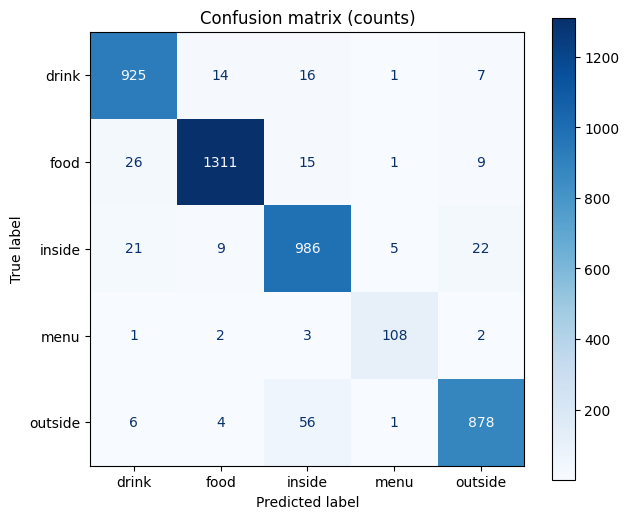


Normalized confusion matrix (by true class, i.e. recall per class):


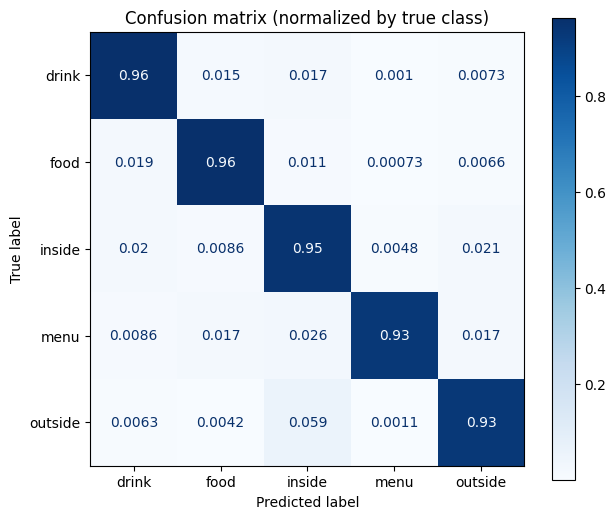

In [18]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("\nFinal model evaluation:")
model.load_state_dict(torch.load("../data/best_vision_model.pth"))
_, final_acc, y_true, y_pred = evaluate(model, val_loader, criterion)

target_names = le.classes_

accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nRaw result of Fine-Tuned BERT (without images):")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix (numeric)
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix (rows=true, cols=predicted):")

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=target_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (counts)")
plt.show()

# Normalized confusion matrix (by true label / recall per class)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
print("\nNormalized confusion matrix (by true class, i.e. recall per class):")

fig, ax = plt.subplots(figsize=(7, 6))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=target_names)
disp_norm.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion matrix (normalized by true class)")
plt.show()